text

# Hypolimnetic oxygen consumption in a lake - 
# A 1-box model study

## Martin Schmid, Exercise 1, FS 2026

Import your packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math

#ahm model 
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt 


## Question 1: Solution with Euler

Set your model parameters, time grid and initial conditions

In [2]:
# Exercise 1: 1-box-model

# ------------------------Model Parameters-------------------------------
z_h = 17.0              # depth of hypolimnion [m]
D_O2 = 1.08E-4          # diffusion coefficient [m*m/d]
F_red = 0.36            # flux of reduced substances from the sediment [g O2/m*m*d]
delta = 0.82E-3         # diffusive boundary layer thickens [m]

# ------------------------Time grid--------------------------------------
t0 = 0.0                # initial time [d]
tend = 200.             # final time [d]
dt = 1.0                # time step [d]
n_grid = int((tend-t0)/dt + 1) # +1 is needed, because the number of grid points includes t0 and tend
tspace = np.linspace(t0, tend, n_grid) # + 1 is needed, because arange excludes the last value

# ------------------------Initial condition------------------------------
C0 = 11.0               # initial concentration [g/m*m*m]a t=0

Execute the Euler Model

In [3]:
# ------------------------Execute Euler model----------------------------
"""
Set the first element of the concentration vector equal to the initial concentration value
Define the time vector (optional!)
Create a for loop to compute the equation
(Remember, len(x) to find the length of x, range(i, j) to obtain all numbers from i to j-1)
"""
C1 = np.zeros_like(tspace)  #allocate memory for the solution
C1[0] = C0
prev = C1[0]
for i in range(1, len(C1)):
    C1[i] = prev - ((F_red/z_h)+D_O2/delta/z_h*prev)*dt
    prev = C1[i]

Plot your results

Text(0, 0.5, 'Hypolimnetic O${_2}$ concentration [g m$^{-3}$]')

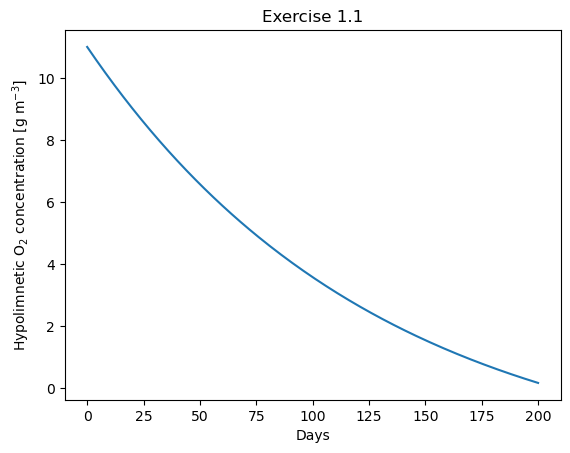

In [4]:
# ------------------------Plot results----------------------------------
plt.plot(tspace, C1)
plt.title("Exercise 1.1")
plt.xlabel("Days")
plt.ylabel("Hypolimnetic O${_2}$ concentration [g m$^{-3}$]")

## Question 2: depth effect

Calculate solution for hypolimnion depths of 7 and 32 m

In [5]:
z_h2 = 7
C2 = np.zeros_like(tspace)
C2[0] = C0
prev = C2[0]

for i in range(1, len(C2)):
    C2[i] = prev - ((F_red/z_h2)+D_O2/delta/z_h2*prev) * dt
    prev = C2[i]

z_h3 = 37
C3 = np.zeros_like(tspace)
C3[0] = C0
prev = C3[0]
for i in range(1, len(tspace)):
    C3[i] = prev - ((F_red/z_h3)+D_O2/delta/z_h3*prev) * dt
    prev = C3[i]

Plot your results

Text(0, 0.5, 'Hypolimnetic O${_2}$ concentration [g m$^{-3}$]')

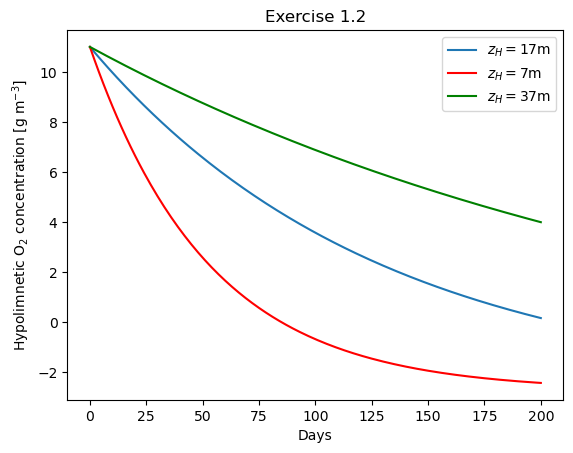

In [6]:
# ------------------------Plot results----------------------------------
plt.plot(tspace, C1, label="$z_H = 17$m")
plt.plot(tspace, C2, 'r', label="$z_H = 7$m")
plt.plot(tspace, C3, 'g', label="$z_H = 37$m")
plt.legend()
plt.title("Exercise 1.2")
plt.xlabel("Days")
plt.ylabel("Hypolimnetic O${_2}$ concentration [g m$^{-3}$]")

## Question 3: solution with ode45

Use scipy's solve_ivp solver to solve your equation numerically

To this end, first define a function depletion that the solver can use:

In [7]:
def depletion(t, c):
    z = 17
    D_O2 = 1.08E-4
    F_r = 0.36
    dbl = 0.82E-3
    return -F_r/z - D_O2/dbl/z*c

Now, set up and apply solve_ivp

In [8]:
# ------------------------Solve with ode45-------------------------------
# use scipy's solve_ivp function along with the depletion function
# define time start and end, initial value, time nodes as t_eval, and the method (as a string!)
"""
Integration method reminder:
‘RK45’ (default): Explicit Runge-Kutta method of order 5(4). Works with complex numbers. Best used for non-stiff problems.
‘RK23’: Explicit Runge-Kutta method of order 3(2). Works with complex numbers. Best used for non-stiff problems.
‘Radau’: Implicit Runge-Kutta method of the Radau IIA family of order 5. Best used for stiff problems.
‘BDF’: Implicit multi-step variable-order (1 to 5) method 
       based on a backward differentiation formula for the derivative approximation. Works with complex numbers. Best used for stiff problems.
‘LSODA’: Adams/BDF method with automatic stiffness detection and switching [7], [8]. This is a wrapper of the Fortran solver from ODEPACK.
         Can work with both non-stiff and stiff problems.
         
If unsure whether problem is unstiff, try RK45 or RK23 first.
More detailed info about solve_ivp and the methods can be found at: 
https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
"""


solved = solve_ivp(depletion, t_span=(t0, tend), y0=np.array([C0]), t_eval=tspace, method='RK45')
#or shorter
#solved = solve_ivp(depletion, (t0, tend), [C0], t_eval=tspace, method='RK45')

Plot your results

Text(0, 0.5, 'Hypolimnetic O${_2}$ concentration [g m$^{-3}$]')

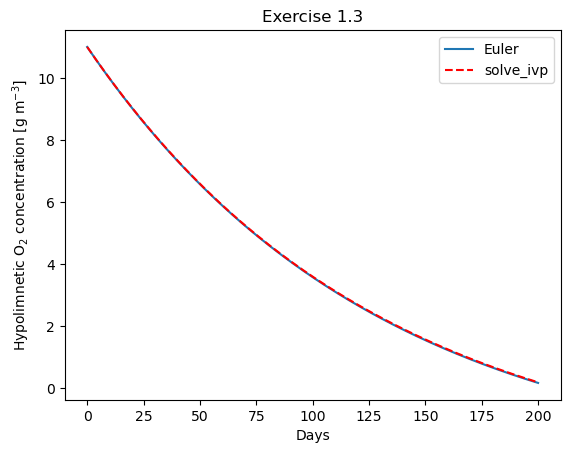

In [9]:
# --------------------------Plot results---------------------------------
plt.plot(tspace, C1, label="Euler")
plt.plot(solved.t, solved.y[0], 'r--', label="solve_ivp")
plt.legend()
plt.title("Exercise 1.3")
plt.xlabel("Days")
plt.ylabel("Hypolimnetic O${_2}$ concentration [g m$^{-3}$]")

## Question 4: compare to field observations

Calculate AHM from lake observations

In [10]:
# ------------------------Calculate AHM rate-----------------------------
"""
Here a nested loop is the easiest solution. The outer loop iterates for
all hypolimnion depths, the inner loop calculates the solution for each
individual zH(i).
"""
#Available Data 
# Lake Data from the figure
depths = np.array([4.2, 5.5, 7, 11.5, 12, 20.1, 22.6, 27.6, 33.8, 38.8, 151])
ahm_data = np.array([0.47, 0.61, 0.6, 0.71, 0.84, 1.03, 1.13, 1.17, 1.2, 1.32, 1.41])


zhi = np.arange(5, 160, 1.0)
ahm_calc = np.zeros_like(zhi)
C4 = np.zeros_like(tspace)

for i in range(0, len(zhi)):
    C4[0] = C0
    prev = C4[0]

    for j in range(1, len(C4)):
        C4[j] = prev - ((F_red / zhi[i]) + D_O2 / delta / zhi[i] * prev) * dt
        prev = C4[j]

    ahm_calc[i] = (C4[0] - C4[-1]) / (tend - t0) * zhi[i]  # x[-1] takes last element, x[-2] takes second to last, etc.


Plot your results

Text(0.5, 1.0, 'Exercise 1.4')

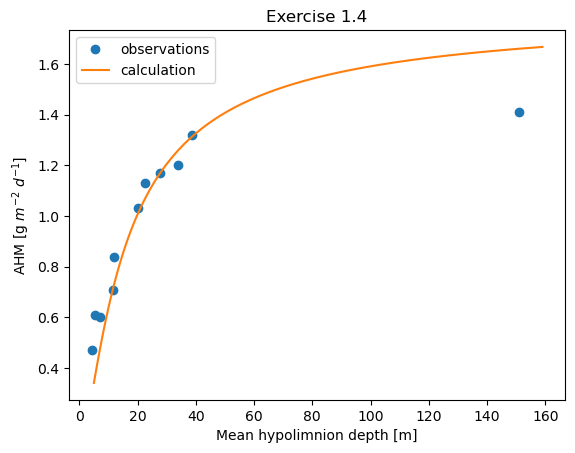

In [11]:
# --------------------------Plot results---------------------------------
plt.plot(depths, ahm, 'o', label="observations")
plt.plot(zhi, ahm_calc, label="calculation")
plt.legend()
plt.ylabel('AHM [g $m^{-2}$ $d^{-1}$]')
plt.xlabel('Mean hypolimnion depth [m]')
plt.title('Exercise 1.4')

## Question 5: compare with analytical solution

Calculate the analytical solution

In [12]:
# ------------------------Analytical solution----------------------------
"""
Equation to solve: dC/dt=-F/z-DO2/delta/zh*C
Solution of inhomogeneous differential equation y'(t)= a - k*y(t) is y(t) = a/k + (y(0)-a/k)*exp(-kt)
Here k=DO2/delta/z and a=-Fred/z
Solution: C(t)=(C(0)-a/k)*exp(-kt)+a/k
"""

# with the basic Python math.exp function for the exponential, you have to create
# a for loop to calculate the solution for each time step.
t_an = np.linspace(0, 200, 201)
C_an = np.zeros_like(t_an)
a = -F_red/z_h
k = D_O2/delta/z_h
for i in range(0, len(t_an)):
    C_an[i] = (C0 - a/k) * math.exp(-k*t_an[i]) + a/k
    
# alternatively, you can use the exponential function of numpy, which allows
# calculating the solution for the entire time vector at once.    

# C_an = (C0 - a/k) * np.exp(-k*t_an) + a/k

  
#    further alternative options for the loop

#    C_an = np.array([(C0 - a/k) * math.exp(-k*t_an_value) + a/k for t_an_value in t_an])
#    C_an = np.array(map(lambda t_an_value: (C0 - a/k) * math.exp(-k*t_an_value) + a/k), t_an)



Plot your results

Text(0.5, 1.0, 'Exercise 1.5a')

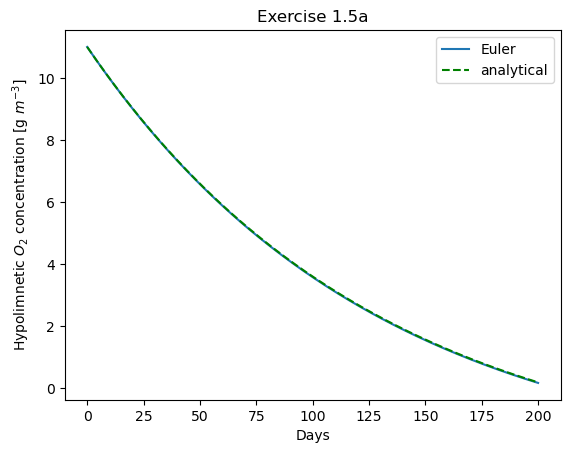

In [13]:
# --------------------------Plot results---------------------------------
plt.plot(tspace, C1, label="Euler")
plt.plot(t_an, C_an, 'g--', label="analytical")
plt.legend()
plt.ylabel('Hypolimnetic $O_2$ concentration [g $m^{-3}$]')
plt.xlabel('Days')
plt.title('Exercise 1.5a')

Euler for different time steps

In [14]:
# -----------------Euler for different time steps------------------------
"""
Note: For different time steps, the resulting arrays of time grids (ts) and the solution (C_ts)
are of different length. Numpy arrays can only include items of the same type and shape.
But Python lists can hold anything of any size. If you want to create a loop for 
solving the equation for different time steps, this can therefore be done by saving the 
results in Python lists ts_all (for the time grids) and C_ts_all (for the solutions).
For each time step dts, the numpy arrays ts and C_ts are then created within the loop,
 and can then be appended to the list at the end, using ts_all.append() and C_ts_all.append().
The problem can also be solved without such lists, but then a loop has to be coded for each 
individual dts.
"""
dts = [5.0, 10.0, 20.0, 50.0]
ts_all = [] # empty list for time steps
C_ts_all = [] # empty list for solutions

for j in range(0, len(dts)): # Loop over time steps
    ts = np.arange(t0, tend, dts[j])
    C_ts = np.zeros_like(ts) # zeros_like(ts) returns an array full of zeros of the shape of ts
    C_ts[0] = C0
    prev = C_ts[0]  # To hold the previous result

    for i in range(1, len(C_ts)): #loop for solving differential equation with time step j
        C_ts[i] = prev - ((F_red / z_h) + D_O2 / delta / z_h * prev)*dts[j]
        prev = C_ts[i]

    ts_all.append(ts) # Adds time grid ts to the list ts_all
    C_ts_all.append(C_ts)  # Adds solution C_ts to the list C_ts_all

Plot your results

Text(0.5, 1.0, 'Exercise 1.5b')

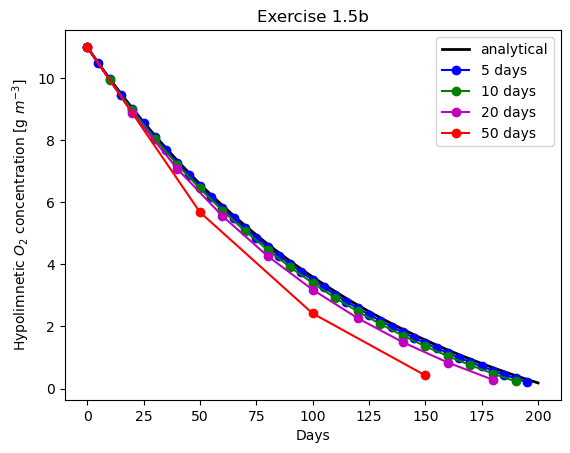

In [15]:
# --------------------------Plot results---------------------------------
plt.plot(t_an, C_an, 'k', linewidth=2)
plt.plot(ts_all[0], C_ts_all[0], 'bo-', ts_all[1], C_ts_all[1], 'go-', ts_all[2], C_ts_all[2], 'mo-', ts_all[3], C_ts_all[3], 'ro-')
# You can add labels like this instead of in each line directly
plt.legend(['analytical', '5 days', '10 days', '20 days', '50 days'])
plt.ylabel('Hypolimnetic $O_2$ concentration [g $m^{-3}$]')
plt.xlabel('Days')
plt.title('Exercise 1.5b')

Now, display all the above figure in one graph (copy and paste all labels, titles and legends)

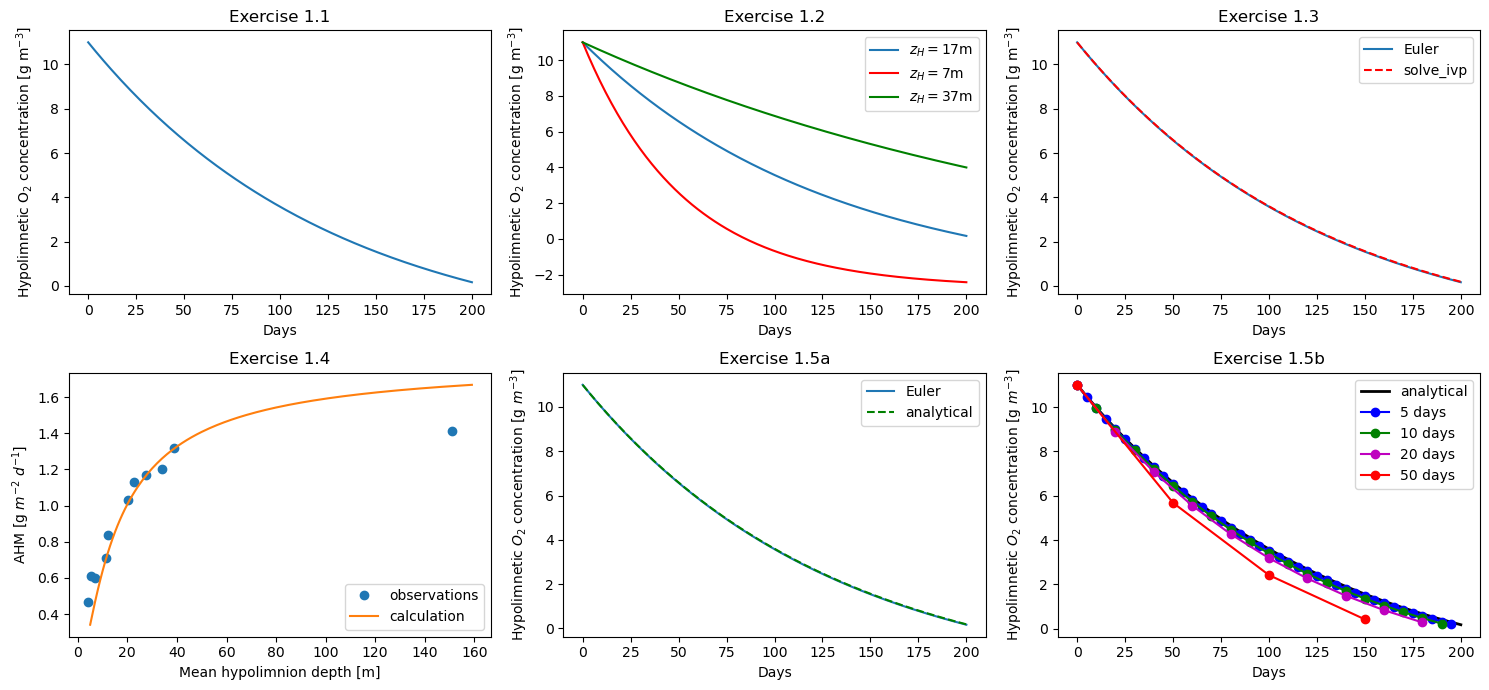

In [16]:
# Set up plot
plt.figure(figsize=(15, 7))

# ------------------------Subplot 1----------------------------------
plt.subplot(2, 3, 1)  # 2 rows, 3 columns, plot number 1
plt.plot(tspace, C1)
plt.title("Exercise 1.1")
plt.xlabel("Days")
plt.ylabel("Hypolimnetic O${_2}$ concentration [g m$^{-3}$]")

# ------------------------Subplot 2----------------------------------
plt.subplot(2, 3, 2)
plt.plot(tspace, C1, label="$z_H = 17$m")
plt.plot(tspace, C2, 'r', label="$z_H = 7$m")
plt.plot(tspace, C3, 'g', label="$z_H = 37$m")
plt.legend()
plt.title("Exercise 1.2")
plt.xlabel("Days")
plt.ylabel("Hypolimnetic O${_2}$ concentration [g m$^{-3}$]")

# --------------------------Subplot 3---------------------------------
plt.subplot(2, 3, 3)
plt.plot(tspace, C1, label="Euler")
plt.plot(solved.t, solved.y[0], 'r--', label="solve_ivp")
plt.legend()
plt.title("Exercise 1.3")
plt.xlabel("Days")
plt.ylabel("Hypolimnetic O${_2}$ concentration [g m$^{-3}$]")

# --------------------------Subplot 4---------------------------------
plt.subplot(2, 3, 4)
plt.plot(depths, ahm, 'o', label="observations")
plt.plot(zhi, ahm_calc, label="calculation")
plt.legend()
plt.ylabel('AHM [g $m^{-2}$ $d^{-1}$]')
plt.xlabel('Mean hypolimnion depth [m]')
plt.title('Exercise 1.4')

# --------------------------Subplot 5---------------------------------
plt.subplot(2, 3, 5)
plt.plot(tspace, C1, label="Euler")
plt.plot(t_an, C_an, 'g--', label="analytical")
plt.legend()
plt.ylabel('Hypolimnetic $O_2$ concentration [g $m^{-3}$]')
plt.xlabel('Days')
plt.title('Exercise 1.5a')

# --------------------------Subplot 6---------------------------------
plt.subplot(2, 3, 6)
plt.plot(t_an, C_an, 'k', linewidth=2)
plt.plot(ts_all[0], C_ts_all[0], 'bo-', ts_all[1], C_ts_all[1], 'go-', ts_all[2], C_ts_all[2], 'mo-', ts_all[3], C_ts_all[3], 'ro-')
# You can add labels like this instead of in each line directly
plt.legend(['analytical', '5 days', '10 days', '20 days', '50 days'])
plt.ylabel('Hypolimnetic $O_2$ concentration [g $m^{-3}$]')
plt.xlabel('Days')
plt.title('Exercise 1.5b')

# Display the figures
plt.tight_layout()
plt.show()


/var/folders/fk/60dn0cy51jx_fj73880s1s8m0000gn/T/ipykernel_5381/4165257378.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C[k] = prev - ((F_red / float(zH)) + (D_O2 / delta_value / float(zH) * prev)) * dt
/var/folders/fk/60dn0cy51jx_fj73880s1s8m0000gn/T/ipykernel_5381/4165257378.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  AHM[i, j] = (C[0] - C[-1]) / (tend - t0) * zH


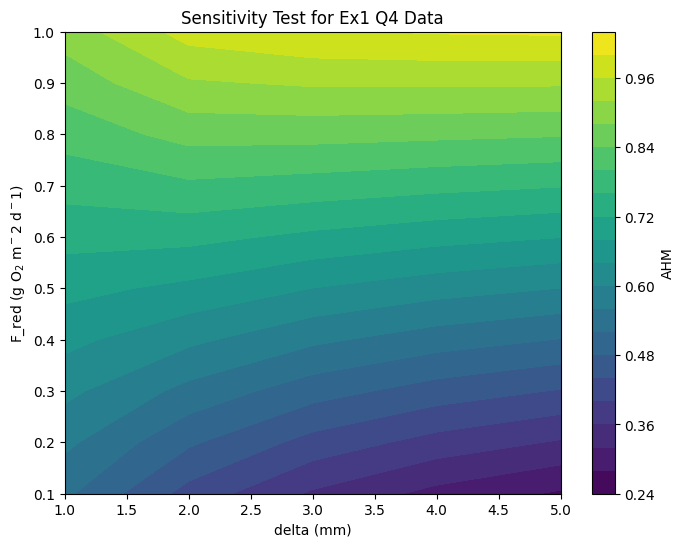

In [16]:
#EXERCISE 5: Q3
#Depths from Exercise 1 Q4 
depths = np.array([4.2, 5.5, 7, 11.5, 12, 20.1, 22.6, 27.6, 33.8, 38.8, 151])
ahm_data = np.array([0.47, 0.61, 0.6, 0.71, 0.84, 1.03, 1.13, 1.17, 1.2, 1.32, 1.41])

p = np.array([0.36, 1.08E-4]) #initial parameter values 

#unit declaration as arrays so they feed into length function in the nested loop 
delta = np.arange(1, 6, 1) * 1e-3   #mm diffusion 
flux = np.arange(0.1, 1.1, 0.1) # m-2 d-1 oxygen consumption 

#at deph of... 
zH = np.array([10]) #to feed into length function in the nested loop 

# within the space of... 
Delta, Flux = np.meshgrid(delta, flux)
AHM = np.zeros_like(Delta)

#time steps, fleshing the grid 
t0 = 0
tend = 200
n_grid = 201
dt = (tend - t0) / (n_grid - 1)
tspace = np.linspace(t0, tend, n_grid)

#initial conditions 
C0 = 11 #concentration 
D_O2 = 1.08E-4 #dissolved oxygen 

C = np.zeros_like(tspace)

#nested loop 
for i in range(len(flux)):
    for j in range(len(delta)):

        F_red = Flux[i, j]
        delta_value = Delta[i, j]

        C[0] = C0
        prev = C[0]

        for k in range(1, len(C)): #string type changed back into float to prevent array from running  
            C[k] = prev - ((F_red / float(zH)) + (D_O2 / delta_value / float(zH) * prev)) * dt
            prev = C[k]

        AHM[i, j] = (C[0] - C[-1]) / (tend - t0) * zH

# Plot
plt.figure(figsize=(8,6))
cp = plt.contourf(DELTA * 1e3, FLUX, AHM, levels=20)
plt.colorbar(cp, label='AHM')

plt.xlabel('delta (mm)')
plt.ylabel('F_red (g O$_2$ m$^-2$ d$^-1$)')
plt.title('Sensitivity Test for Ex1 Q4 Data')

plt.show()

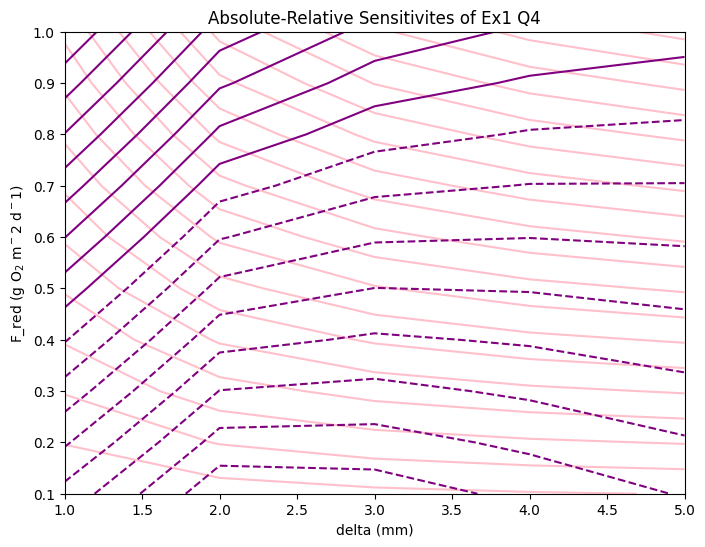

In [26]:
#Exercise 5 Question 2 

#x and y of the grid 
delta = np.arange(1, 6, 1) * 1e-3   #mm diffusion 
flux = np.arange(0.1, 1.1, 0.1) # m-2 d-1 oxygen consumption 

#parameter define 
zH = 10 
C0 = 11 
DO2 = 1.084E-4
calc_x = np.zeros_like(Delta) #storage 
calc_y = np.zeros_like(Delta) 

#put it into a grid 

Delta, Flux = np.meshgrid(delta,flux) 

#AHM_storage = np.zeros_like(Delta) 
#Fred = np.zeros_like(Delta) 
#delta_storage = np.zeros_like(Delta) 

#t0, tend = 0, 200 #conditions 
#n_grid = 201 #iterations 
#dt = (tend - t0) / (n_grid - 1) #time step 

#nested loop 
def ahm_calc(zH, F_red, delta):
    C0 = 11
    t0, tend = 0, 200
    dt = 1

    grid = np.arange(t0, tend + dt, dt)
    C = np.zeros(len(grid))

    C[0] = C0
    for j in range(len(grid) - 1): #iteration 
        C[j+1] = C[j] - ((F_red / zH) + (DO2 / delta / zH * C[j])) * dt

    return (C[0] - C[-1]) / (tend - t0) * zH
    
for i in range (len(flux)):
    for j in range(len(delta)): 
        x = Flux[i, j] 
        y = Delta[i, j] 
        base = ahm_calc(zH, x , y) 

        dx = 0.001 * x 
        dy = 0.001 * y 

        calc_x[i, j] = (ahm_calc(zH, x + dx, y) - base) / dx * x 
        calc_y[i, j] = (ahm_calc(zH, x, y + dy) - base) / dy * y 

plt.figure(figsize=(8,6))
plt.contour(Delta * 1e3, Flux, calc_x, levels = 20, colors = 'pink')
plt.contour(Delta * 1e3, Flux, calc_y, levels = 20, colors = 'purple')


plt.xlabel('delta (mm)')
plt.ylabel('F_red (g O$_2$ m$^-2$ d$^-1$)')
plt.title('Absolute-Relative Sensitivites of Ex1 Q4')

plt.show()

#When comparing to the previous model, we see the absolute-relativity is much
#more sensitive to diffusion of oxygen, with inreasing slopes beyond 1.0. The
#previous model had plateued by this point at around 2 mm. Therefore, this
#absolute-relative sensitivity model does better are creating identifiable 
#data between the parameters. 

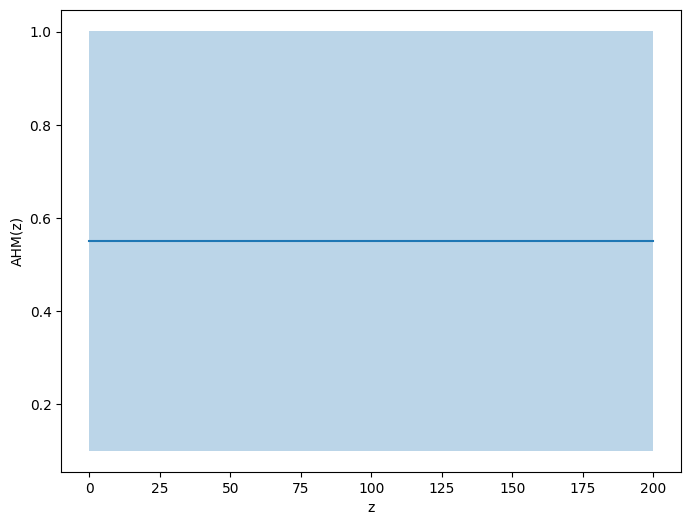

In [39]:
#Exercise 5 Question 4

#x and y of the grid 
delta_assumption = np.linspace(1e-3, 5e-3, 5) #continous, linspace 
delta_min, delta_max = 0.5 * delta_assumption.min(), 2.0 * delta_assumption.max() 

flux_assumption = np.linspace(0.1, 1.1, 10) # m-2 d-1 oxygen consumption 
flux_min, flux_max = 0.5 * flux_assumption.min(), 1.5 * flux_assumption.max()

#parameter define 
zH = 10 
C0 = 11 
DO2 = 1.084E-4

delta = np.linspace(delta_min, delta_max, 20)  
delta = np.linspace(flux_min, flux_max, 20) 

#put it into a grid 

Delta, Flux = np.meshgrid(delta,flux) 


#nested loop 
def ahm_calc(zH, F, delta):
    C0 = 11
    t0, tend = 0, 200
    dt = 1

    grid = np.arange(t0, tend + dt, dt)
    C = np.zeros(len(grid))

    C[0] = C0
    
    for j in range(len(grid) - 1): #iteration 
        C[j + 1] = C[j] - (((F / zH) + (DO2 / (delta * zH) * C[j])) * dt)

    result = (C[0] - C[-1]) / (tend - t0) * zH
    return result
            
store_F = len(flux)
store_D = len(delta) 
       
AHM_z = np.zeros((store_F, store_D, 201))
     
for i in range (store_F):
    for j in range(store_D): 
        AHM_z[i, j, :] = ahm_calc(zH, Flux[i, j], Delta[i, j]) 
        

AHM_min = np.min(AHM_z, axis = (0,1))
AHM_max = np.max(AHM_z, axis = (0, 1))
AHM_mean = np.mean(AHM_z, axis= (0,1))

z = np.arange(0, 201, 1) 

extreme_min = (Delta.min(), Flux.min())
extreme_max = (Delta.max(), Flux.max())

               
plt.figure(figsize=(8,6))
plt.fill_between(z, AHM_min, AHM_max, alpha=0.3)
plt.plot(z, AHM_mean) 
plt.xlabel('z')
plt.ylabel('AHM(z)')

plt.show()

#Obviously incorrect, but I've hit the deadline. 